# 04 · Нормы: эталон для сравнения бросков

Логика — `src/norms.py`; артефакты — `throw_intent.parquet`, `lineup_norms.parquet`, `tier_norms.parquet`.

**Привязка по намерению** (в 03 — по месту падения, промахи терялись):
- тот же тип и сторона;
- стоял ближе `max(64, 2 × разброс точки броска)` к точке броска раскидки;
- прицел ±5° (флешки ±10°).

**Попадание** = падение ближе `max(100, 2 × разброс падения)` к центру раскидки; при нескольких кандидатах — та, куда реально упало.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import norms as N
from metrics import load_throws, RATING_LABELS
from mapviz import draw_map, draw_lineups

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3})

throws = load_throws()
lineups = pd.read_parquet("../data/lineups.parquet")
intent = pd.read_parquet("../data/throw_intent.parquet")
lineup_norms = pd.read_parquet("../data/lineup_norms.parquet")
tier_norms = pd.read_parquet("../data/tier_norms.parquet")

throws_intent = throws.merge(intent, on="grenade_id")
throws_intent["speed"] = np.hypot(throws_intent.vel_x, throws_intent.vel_y)
print(
    f"бросков с намерением: {len(throws_intent):,} из {len(throws):,} ({len(throws_intent)/len(throws):.0%}) "
    f"| попаданий: {throws_intent.hit.mean():.0%}"
)

бросков с намерением: 1,293,622 из 2,385,417 (54%) | попаданий: 75%


## 1. Покрытие и попадания

In [2]:
by_landing = pd.read_parquet("../data/throw_lineup.parquet")
both_links = by_landing.merge(intent, on="grenade_id", how="outer")
pd.Series(
    {
        "в раскидке по месту падения (03)": by_landing.grenade_id.nunique(),
        "в раскидке по намерению (04)": len(intent),
        "  из них промахи": int((~intent.hit).sum()),
        "совпадение раскидки там, где есть обе привязки": (both_links.dropna().lineup_id == both_links.dropna().intent_id).mean().round(3),
    },
    name="",
).to_frame()

,
в раскидке по месту падения (03),1214143.000
в раскидке по намерению (04),1293622.000
из них промахи,324472.000
"совпадение раскидки там, где есть обе привязки",0.814


In [3]:
throws_intent.groupby(["type", "side"], observed=True).hit.agg(["size", "mean"]).rename(
    columns={"size": "попыток", "mean": "попаданий"}
).unstack().round(2)

попыток         попаданий      
side       CT       T        CT     T
type                                 
fire   155349  100436      0.78  0.77
flash  121265  204729      0.69  0.68
he     186557  116215      0.78  0.73
smoke  231284  177787      0.84  0.69

## 2. Как выглядят попадания и промахи

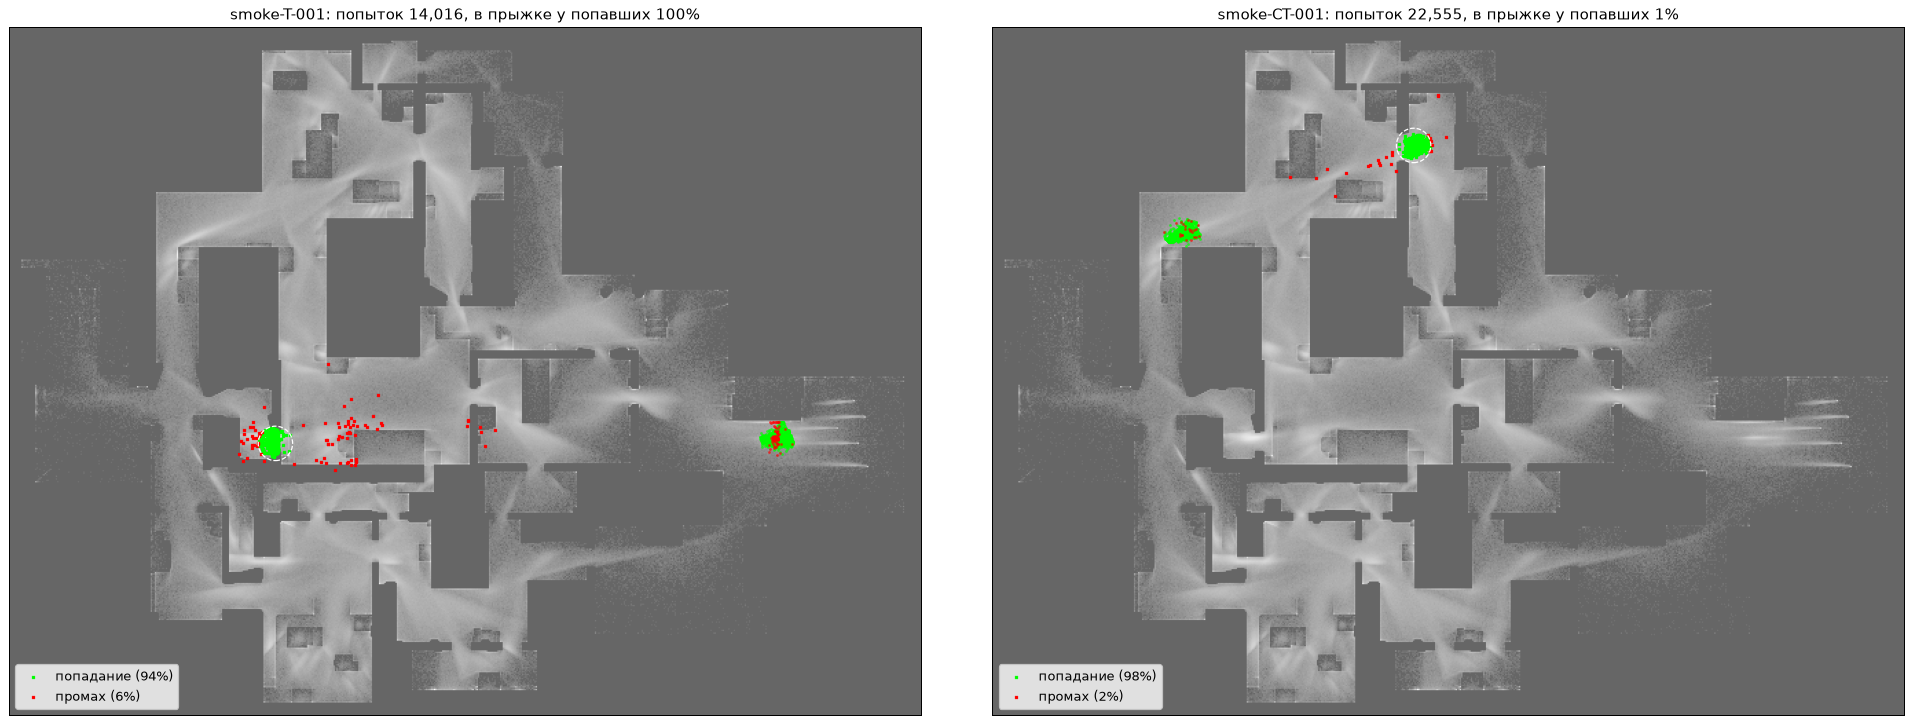

In [4]:
def show_attempts(lineup_id, ax, sample_size=1500):
    attempts = throws_intent[throws_intent.intent_id == lineup_id].sample(
        min(sample_size, (throws_intent.intent_id == lineup_id).sum()), random_state=0
    )
    ref = lineups.loc[lineup_id]
    draw_map(ax, alpha=0.6)
    for hit, color in [(True, "lime"), (False, "red")]:
        subset = attempts[attempts.hit == hit]
        label = ("попадание" if hit else "промах") + f" ({(attempts.hit == hit).mean():.0%})"
        ax.scatter(subset.land_x, subset.land_y, s=4, color=color, marker="x", label=label)
        ax.scatter(subset.throw_x, subset.throw_y, s=2, color=color, alpha=0.5)
    ax.add_patch(
        plt.Circle((ref.land_cx, ref.land_cy), max(N.HIT_R, 2 * ref.land_spread), fill=False, color="white", ls="--")
    )
    ax.set_title(
        f"{lineup_id}: попыток {lineup_norms.loc[lineup_id, 'attempts']:,}, "
        f"в прыжке у попавших {lineup_norms.loc[lineup_id, 'airborne_hit']:.0%}"
    )
    ax.legend(loc="lower left")


fig, axs = plt.subplots(1, 2, figsize=(22, 8))
show_attempts("smoke-T-001", axs[0])
show_attempts("smoke-CT-001", axs[1])
plt.tight_layout()

## 3. Проверка 1: попадания растут с рейтингом

type,fire,flash,he,smoke
rating_tier,,,,
<5k,72.3,65.2,72.0,69.9
5-10k,75.1,68.1,73.4,72.5
10-15k,77.5,69.0,75.3,75.5
15-20k,79.6,69.0,77.3,79.7
20-25k,81.3,69.2,79.0,82.2
25k+,82.7,67.9,78.4,83.3


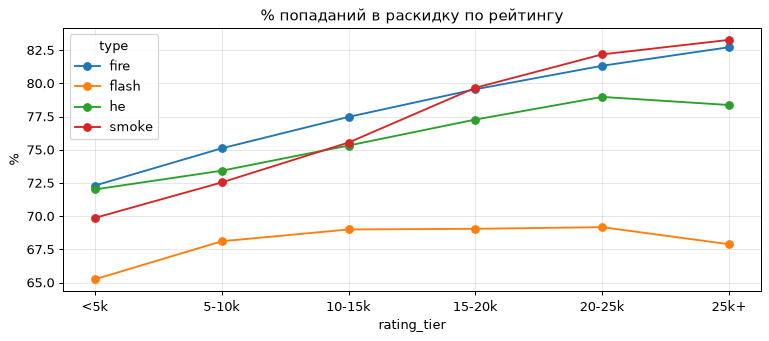

In [5]:
rated = throws_intent[throws_intent.rating_tier.notna()]
hit_by_tier = rated.groupby(["rating_tier", "type"], observed=True).hit.mean().unstack().mul(100)
ax = hit_by_tier.plot(marker="o", figsize=(10, 3.8), title="% попаданий в раскидку по рейтингу")
ax.set_ylabel("%")
hit_by_tier.round(1)

## 4. Проверка 2: техника объясняет промахи

In [6]:
throws_intent = throws_intent.join(lineup_norms[["airborne_hit"]], on="intent_id")
throws_intent["lineup_tech"] = np.select(
    [throws_intent.airborne_hit > 0.8, throws_intent.airborne_hit < 0.2],
    ["раскидка в прыжке", "раскидка без прыжка"],
    "смешанная",
)
tech_hits = (
    throws_intent[throws_intent.lineup_tech != "смешанная"]
    .groupby(["type", "lineup_tech", "airborne"], observed=True)
    .hit.agg(["size", "mean"])
    .rename(columns={"size": "попыток", "mean": "попаданий"})
)
tech_hits["попаданий"] = (tech_hits["попаданий"] * 100).round(1)
tech_hits.unstack("airborne")

попыток        попаданий      
airborne                    False  True      False True 
type  lineup_tech                                       
fire  раскидка без прыжка  245282    234      78.0  17.1
      раскидка в прыжке      1636   8633       0.6  87.8
flash раскидка без прыжка  297649   6905      70.4  26.8
      раскидка в прыжке       673  18043      22.4  51.8
he    раскидка без прыжка  296925    933      76.5  13.4
      раскидка в прыжке       902   2402       0.1  79.8
smoke раскидка без прыжка  329164   2012      80.7  34.8
      раскидка в прыжке      1125  74087       1.7  69.1

Эффект огромный: смок «в прыжке» без прыжка — **1.7%** против 69% с прыжком.
Оговорка: если есть альтернативная раскидка без прыжка с той же точки, бросок привяжется к ней.

**Движение** (только раскидки без прыжка):

In [7]:
throws_intent["moving"] = pd.cut(throws_intent.speed, [-1, 10, 150, 1000], labels=["стоял", "шёл", "бежал"])
movement_hits = throws_intent[throws_intent.airborne_hit < 0.2].groupby(["type", "moving"], observed=True).hit.agg(["size", "mean"])
movement_hits["mean"] = (movement_hits["mean"] * 100).round(1)
movement_hits.rename(columns={"size": "попыток", "mean": "попаданий %"}).unstack("moving")

попыток                попаданий %            
moving   стоял    шёл   бежал       стоял   шёл бежал
type                                                 
fire     22708  55790  167018        66.8  74.1  80.7
flash    43726  67144  193684        64.3  62.9  72.7
he       27237  78587  192034        58.8  67.3  82.4
smoke    52009  58595  220572        81.9  74.2  81.7

Движение само по себе **не ошибка**: молотовы и HE на бегу попадают даже чаще (80–82% против 59–67% стоя) —
это стандартные «run-throw» раскидки. Ошибкой является только техника, отличная от нормы конкретной раскидки (как с прыжком).

## 5. Что стоит промах

In [8]:
flashes = throws_intent[throws_intent.type == "flash"]
flash_by_hit = flashes.groupby("hit").flash_result.value_counts(normalize=True).unstack().mul(100).round(1)
flash_by_hit["врагов ослеплено"] = flashes.groupby("hit").enemy_blind.mean().round(2)
flash_by_hit["своих ослеплено"] = flashes.groupby("hit").apply(lambda g: (g.team_blind + g.self_blind).mean()).round(2)
display(flash_by_hit.rename(index={True: "флешка: попал", False: "флешка: промах"}))

damage_by_hit = throws_intent[throws_intent.type.isin(["he", "fire"])].groupby(["type", "hit"], observed=True).enemy_dmg.agg(
    ["mean", lambda s: (s == 0).mean() * 100]
)
damage_by_hit.columns = ["средний урон", "без урона %"]
damage_by_hit.round(1)

flash_result,полезная,размен,вредная,пустая,врагов ослеплено,своих ослеплено
hit,,,,,,
флешка: промах,28.5,8.6,17.8,45.1,0.49,0.33
флешка: попал,33.5,7.0,12.4,47.2,0.54,0.23


средний урон  без урона %
type hit                             
fire False           2.1         88.7
     True            2.5         86.0
he   False           8.9         64.5
     True            9.9         60.6

Для смоков исхода нет — промах смока оцениваем только геометрически (дым встал не там).

## 6. Нормы раскидок: лучшие и худшие флешки

In [9]:
norm_cols = [
    "attempts", "hit_rate", "airborne_hit", "enemy_blind", "own_blind",
    "flash_полезная", "flash_вредная", "flash_пустая", "flash_kill_100",
]
flash_norms = lineup_norms[lineup_norms.index.str.startswith("flash") & (lineup_norms.attempts >= 300)][norm_cols]
best_flashes = flash_norms.sort_values("flash_полезная", ascending=False).head(8)
worst_flashes = flash_norms.sort_values("flash_вредная", ascending=False).head(8)
display(best_flashes.round(2))
display(worst_flashes.round(2))

,attempts,hit_rate,airborne_hit,enemy_blind,own_blind,flash_полезная,flash_вредная,flash_пустая,flash_kill_100
lineup_id,,,,,,,,,
flash-CT-103,507,0.89,0.00,1.19,0.18,0.60,0.08,0.24,10.26
flash-CT-010,1460,0.98,0.00,1.17,0.19,0.58,0.09,0.24,8.36
flash-T-004,5874,0.96,0.04,0.88,0.16,0.57,0.06,0.29,3.13
flash-CT-097,456,0.94,0.00,1.09,0.18,0.57,0.09,0.27,7.24
flash-T-052,710,0.85,1.00,1.05,0.29,0.57,0.07,0.20,11.41
flash-T-013,5724,0.8,0.06,0.84,0.15,0.56,0.05,0.32,2.57
flash-T-017,1921,0.85,0.00,0.82,0.25,0.56,0.08,0.27,5.00
flash-T-030,2932,0.93,0.05,0.95,0.23,0.56,0.07,0.25,3.96


,attempts,hit_rate,airborne_hit,enemy_blind,own_blind,flash_полезная,flash_вредная,flash_пустая,flash_kill_100
lineup_id,,,,,,,,,
flash-T-113,487,0.71,0.00,0.17,0.63,0.11,0.50,0.35,2.05
flash-T-130,485,0.39,0.00,0.04,0.86,0.01,0.49,0.48,1.03
flash-CT-068,422,0.62,0.28,0.27,0.78,0.10,0.46,0.32,0.71
flash-T-100,473,0.56,0.00,0.21,0.70,0.15,0.43,0.41,0.21
flash-CT-001,2999,0.75,0.00,0.22,0.60,0.09,0.43,0.41,1.53
flash-CT-027,1328,0.81,0.00,0.19,0.55,0.08,0.40,0.46,1.66
flash-T-006,3026,0.81,0.00,0.11,0.60,0.07,0.40,0.50,0.46
flash-CT-004,708,0.55,0.19,0.41,0.71,0.15,0.39,0.32,4.80


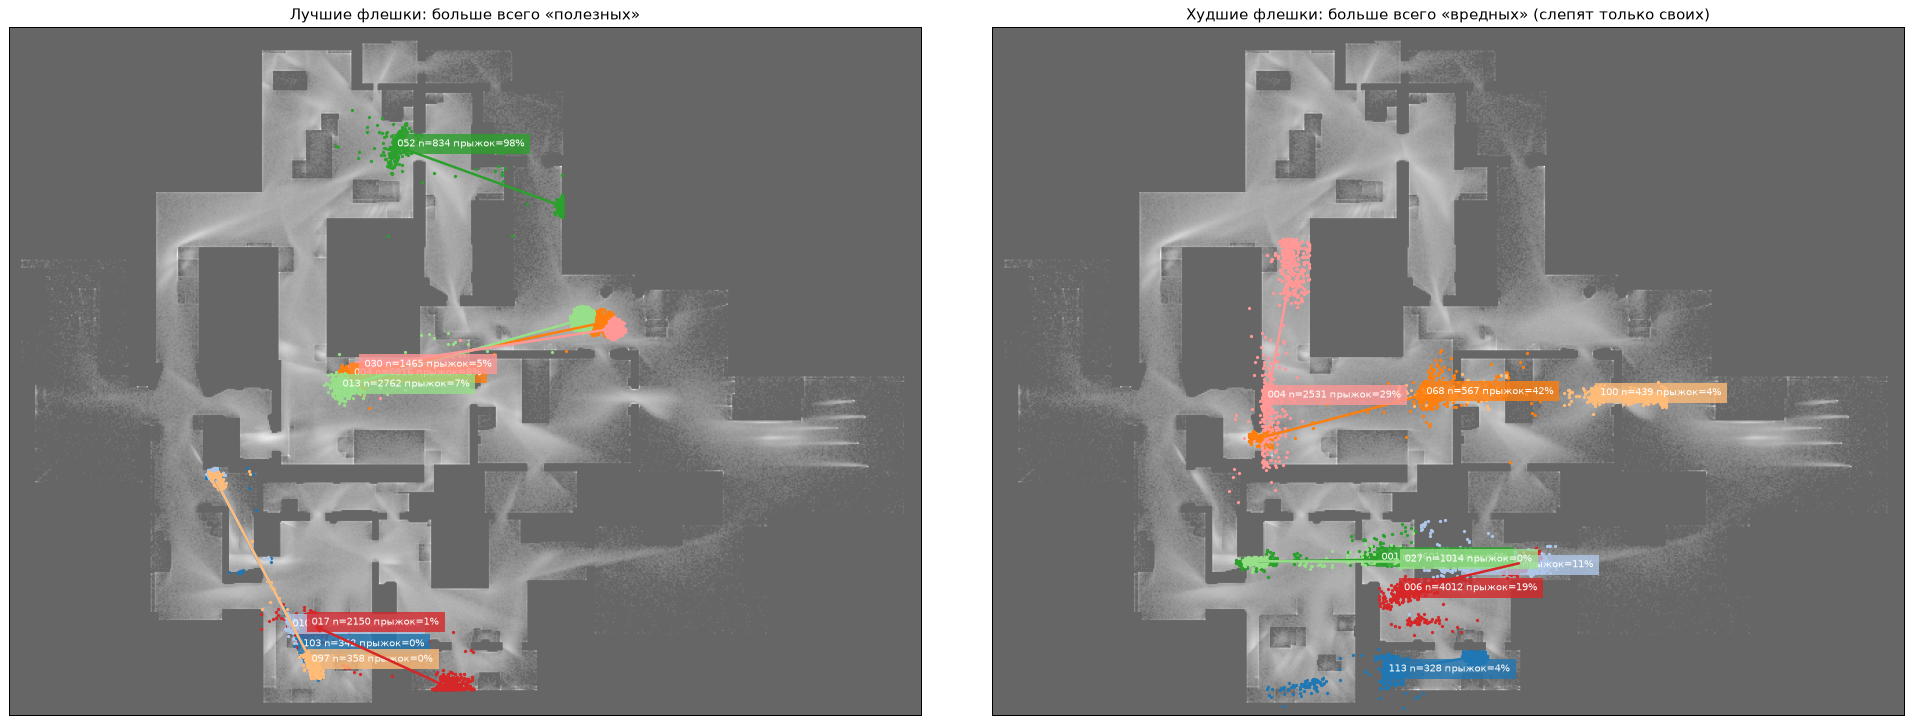

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(22, 8))
draw_lineups(axs[0], lineups.loc[best_flashes.index], throws_intent.rename(columns={"intent_id": "lineup_id"}))
axs[0].set_title("Лучшие флешки: больше всего «полезных»")
draw_lineups(axs[1], lineups.loc[worst_flashes.index], throws_intent.rename(columns={"intent_id": "lineup_id"}))
axs[1].set_title("Худшие флешки: больше всего «вредных» (слепят только своих)")
plt.tight_layout()

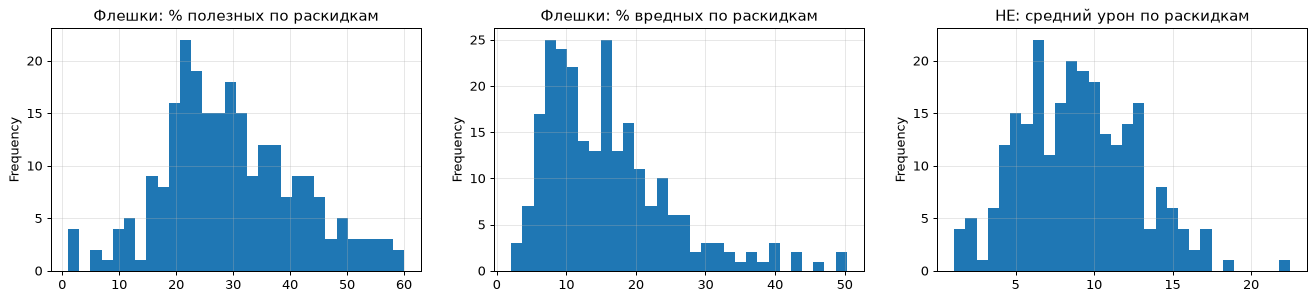

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(18, 3.5))
flash_norms.flash_полезная.mul(100).plot.hist(bins=30, ax=axs[0], title="Флешки: % полезных по раскидкам")
flash_norms.flash_вредная.mul(100).plot.hist(bins=30, ax=axs[1], title="Флешки: % вредных по раскидкам")
lineup_norms[lineup_norms.index.str.startswith("he") & (lineup_norms.attempts >= 300)].enemy_dmg.plot.hist(
    bins=30, ax=axs[2], title="HE: средний урон по раскидкам"
)

Разброс между раскидками огромный: одни флешки полезны в 50%+ случаев, другие почти всегда слепят своих → «какую флешку кидать» — сам по себе совет.

## 7. Нормы по рейтингу (для шкалы «на каком ты уровне»)

,throws,hit_rate,flash_useful,flash_harmful,enemy_blind,he_dmg,fire_dmg
rating_tier,,,,,,,
<5k,44455,0.696,0.248,0.209,0.434,8.093,2.297
5-10k,86294,0.721,0.262,0.189,0.452,8.025,2.407
10-15k,157443,0.742,0.277,0.178,0.477,8.564,2.289
15-20k,179916,0.765,0.292,0.168,0.506,8.905,2.422
20-25k,113705,0.783,0.306,0.162,0.541,9.378,2.602
25k+,19012,0.786,0.327,0.174,0.573,9.713,3.037


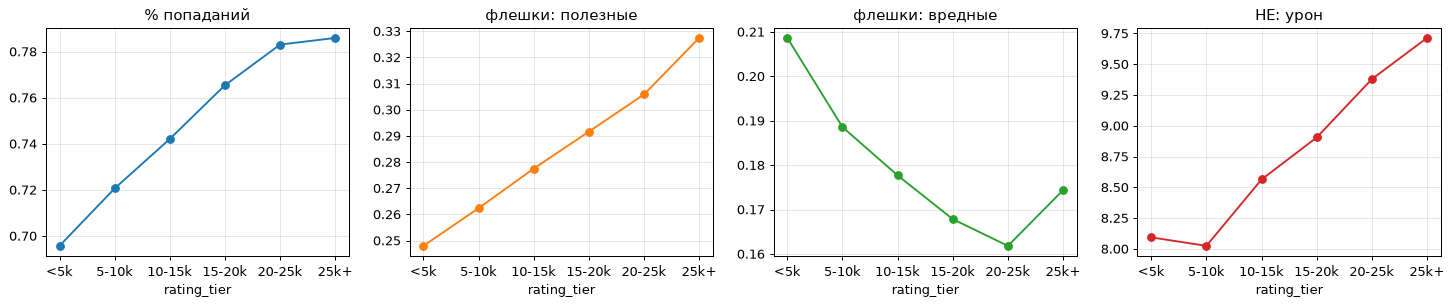

In [12]:
display(tier_norms.round(3))
tier_norms[["hit_rate", "flash_useful", "flash_harmful", "he_dmg"]].plot(
    subplots=True,
    layout=(1, 4),
    figsize=(20, 3.3),
    marker="o",
    legend=False,
    title=["% попаданий", "флешки: полезные", "флешки: вредные", "HE: урон"],
)

## Выводы

1. **Привязка по намерению работает:** 54% бросков привязаны к раскидке, 75% из них попали. Видно 324k промахов, которые при привязке
   по месту падения терялись. Где есть обе привязки, раскидка совпадает в 81%.
2. **Проверка 1 — попадания растут с рейтингом:** смоки 70% → 83%, молотовы 72% → 83%, HE 72% → 78%.
   У флешек почти плоско (65–69%): геометрическое попадание для них слабый показатель (широкий допуск, ситуативные броски) →
   флешки оцениваем по результату (полезная / вредная).
3. **Проверка 2 — техника объясняет промахи:** раскидка «в прыжке» без прыжка — 0–2% попаданий у смоков, HE и молотовов (против 69–88%).
   Это готовое объяснение «почему ты промахиваешься».
4. **Движение — не ошибка** само по себе: многие раскидки делают на бегу.
5. **Промах флешки** → вредных 17.8% вместо 12.4%, своих ослеплено 0.33 вместо 0.23. Промах HE обходится дёшево (8.9 урона против 9.9).
6. **Раскидки сильно различаются по пользе:** лучшие флешки — 56–60% полезных, худшие — 40–50% вредных,
   включая популярные (`flash-CT-001`: ~3 000 попыток, 43% вредных).

**Что готово для персонального совета:**
- (а) не та техника для раскидки;
- (б) раскидка у игрока промахивается чаще нормы;
- (в) раскидка сама по себе плохая, и есть альтернатива получше с того же места;
- (г) уровень игрока по шкале рейтинга.